In [6]:
import os
import glob
import numpy as np
from tqdm import tqdm

import matplotlib.pyplot as plt
from IPython.display import clear_output
%matplotlib inline


import torch
import torch.nn as nn
import torch.nn.functional as F

from dense import *
from resnet import resnet50 as backbone

MIN_W = 640
MAX_W = 800
CROPS = 384

BS = 16
NW = 6
LR = 1e-4
EPOCHS = 20

os.environ["CUDA_VISIBLE_DEVICES"] = "0"
DEVICE_IDS = [0]
device = torch.device("cuda")

torch.manual_seed(0)

criterion = nn.KLDivLoss(reduction='batchmean')


In [8]:
def plot(train_losses, valid_losses, save_path='loss.png'):
    clear_output(True)
    plt.figure(figsize=(20, 6))
    plt.subplot(121)
    if len(train_losses) > 0:
        plt.title('current: {}'.format(train_losses[-1]))
    plt.plot(train_losses)
    plt.grid(True)
    plt.subplot(122)
    if len(valid_losses) > 0:
        plt.title('current: {}, min: {}'.format(
            valid_losses[-1], np.array(valid_losses).min()))
    plt.plot(valid_losses)
    plt.grid(True)
    plt.savefig(save_path)
    plt.show()
    

def train():
    model.train()
#     pbar = tqdm(total=len(trainLD), desc="Training")

    for _, (image, target, condition) in enumerate(trainLD):
        
        image, target = image.to(device), target.to(device)
        target = target / (target.sum(dim=[1, 2, 3], keepdim=True) + 1e-8) # ensure it is never zero
        target = target.view(target.size(0), -1)
        output = model(image)[range(target.size(0)), condition, :, :]
        output = output.view(target.size(0), -1)

        output = F.log_softmax(output, dim=1)
        loss = criterion(output, target)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        train_losses.append(loss.item())
        plot(train_losses=train_losses, valid_losses=valid_losses)
        
#         pbar.set_postfix(loss=loss.item())
#         pbar.update(1)
    
    

def valid():
    model.eval()
    count = 0
    sum_loss = 0.0
    with torch.no_grad():
        for _, (image, target, condition) in enumerate(validLD):
            image, target = image.to(device), target.to(device)
            target = target / target.sum(dim=[1, 2, 3], keepdim=True)
            target = target.view(target.size(0), -1)
            output = model(image)[range(target.size(0)), condition, :, :]
            output = output.view(target.size(0), -1)

            output = F.log_softmax(output, dim=1)
            loss = criterion(output, target)
            count += target.size(0)
            sum_loss += loss.item()
    avg_loss = sum_loss / count
    valid_losses.append(avg_loss)


class Network(nn.Module):
    def __init__(self):
        super(Network, self).__init__()
        self.backbone = backbone(pretrained=True)
        # self.fpn = FPN(in_planes=in_planes, out_planes=out_planes, sizes=sizes)
        self.conv = nn.Conv2d(1024, 18, 1, bias=True)

    def forward(self, x):
        outs = self.backbone(x)
        # outs = self.fpn(outs)

        # size = outs[-1].shape[-2:]
        # outs[0] = upsample(outs[0], size)
        # outs[1] = upsample(outs[1], size)
        # outs[2] = upsample(outs[2], size)
        # out = torch.cat(outs, dim=1)
        out = outs
        # print(out.shape)

        out = self.conv(out)
        # print(out.shape)
        return F.interpolate(out, scale_factor=16, mode='bilinear', align_corners=False)
    
    
trainTransforms = Compose([
    RandomResize(min_w=MIN_W, max_w=MAX_W, ratio=0.625),
    RandomCrop(size=(CROPS, CROPS)), # potentially causing NaN error by cropping empty regions
    RandomHorizontalFlip(0.5),
    ToTensor(),
    Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])
validTransforms = Compose([
    ToTensor(),
    Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])


# train 

In [3]:


class Search(VisionDataset):
    def __init__(self, root, split, transforms=None):
        super(Search, self).__init__(root)
        self.split = split
        self.transforms = transforms
        self.src_dir = root + 'imagesHiLow/320x512/'
        self.tgt_dir = root + 'targetHiLow/' + split + '/'

        targets = ['bottle', 'chair', 'cup', 'fork', 'laptop', 'microwave',
                   'sink', 'stop sign', 'toilet', 'tv', 'bowl', 'car',
                   'clock', 'keyboard', 'knife', 'mouse', 'oven', 'potted plant']
        self.mapping = dict(zip(targets, range(18)))
        self.tgt = []
        self.ann = []
        for target in targets:
            self.tgt += glob.glob(self.tgt_dir + target + '/*.jpg')
            self.ann += [self.mapping[target]] * len(glob.glob(self.tgt_dir + target + '/*.jpg'))

    def __len__(self):
        return len(self.tgt)

    def __getitem__(self, index):
        tgt = Image.open(self.tgt[index])
        ann = self.ann[index]
        path = self.tgt[index].replace('targetHiLow/' + self.split, 'imagesHiLow/320x512/present')
#         path = path.replace(' ', '_')
        src = Image.open(path).convert('RGB')

        if self.transforms is not None:
            src, tgt = self.transforms(src, tgt)
        return src, tgt, ann


root_dir = '/home/young/hdd1/coco-search18/'
trainSet = Search(root_dir, split='train', transforms=trainTransforms)
validSet = Search(root_dir, split='valid', transforms=validTransforms)
# testSet = Search(root_dir, split='test', transforms=validTransforms)
# testSetBlur = Search(root_dir, split='testBlur', transforms=validTransforms)

img, sal, tgt = trainSet[0]
print(len(trainSet), img.size(), sal.size(), tgt)
img, sal, tgt = validSet[0]
print(len(validSet), img.size(), sal.size(), tgt)
# img, sal, tgt = testSet[0]
# print(len(testSet), img.size(), sal.size(), tgt)
# img, sal, tgt = testSetBlur[0]
# print(len(testSetBlur), img.size(), sal.size(), tgt)

11127 torch.Size([3, 384, 384]) torch.Size([1, 384, 384]) 0
1674 torch.Size([3, 320, 512]) torch.Size([1, 320, 512]) 0


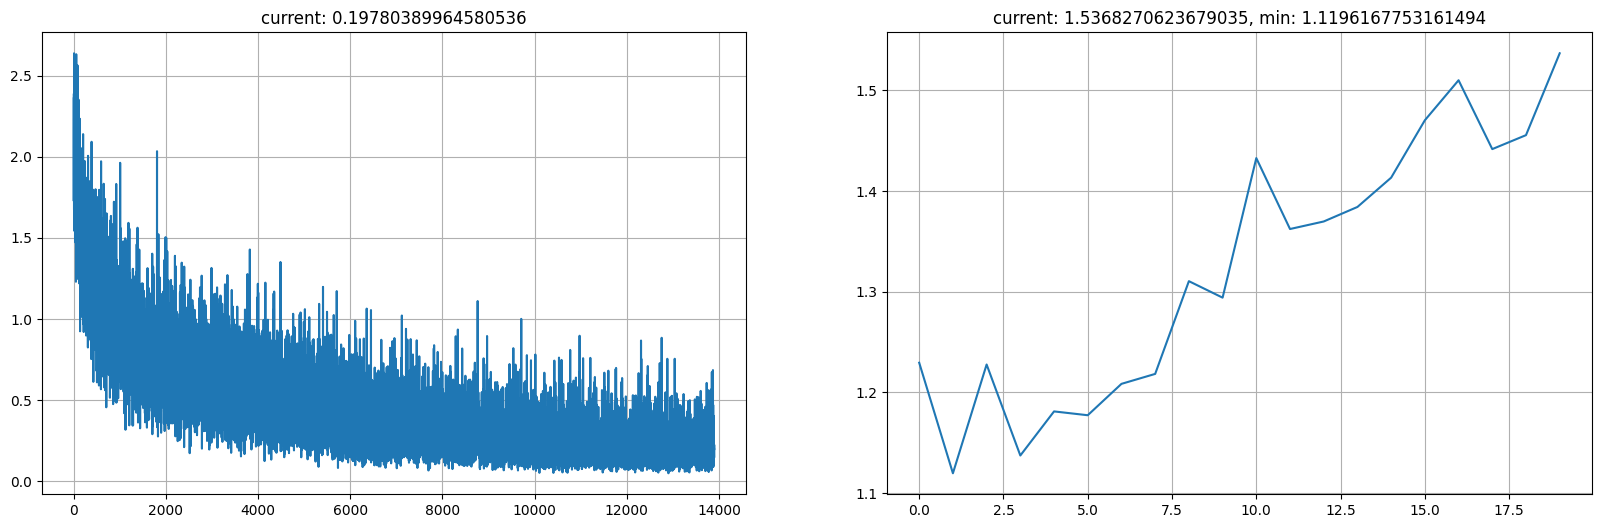

In [ ]:

model = Network()
model_checkpoint= 'detection_hilow_aug.pt'

if len(DEVICE_IDS) > 1:
    model = nn.DataParallel(model, device_ids=DEVICE_IDS)
model = model.to(device)
criterion = criterion.to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=LR)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=5
)

trainSampler = torch.utils.data.RandomSampler(trainSet)
validSampler = torch.utils.data.SequentialSampler(validSet)
trainLD = torch.utils.data.DataLoader(trainSet, drop_last=True,
                                      sampler=trainSampler,
                                      batch_size=BS, num_workers=NW)
validLD = torch.utils.data.DataLoader(validSet, 
                                      sampler=validSampler,
                                      batch_size=1, num_workers=1)

min_kl = 10.0
train_losses = []
valid_losses = []
for _ in range(EPOCHS):
#     print(f'epoch {_}:')
    train()
    valid()
    
    scheduler.step(valid_losses[-1])
    if valid_losses[-1] < min_kl:
        min_kl = valid_losses[-1]
        torch.save(model.state_dict(), model_checkpoint)
        
# plot(train_losses=train_losses, valid_losses=valid_losses, save_path=f'{detection_hilow_aug}.png')

modelname = model_checkpoint.split('.')[0]
plot(train_losses=train_losses, valid_losses=valid_losses, save_path=f'{modelname}_loss.png')

# Generate predictions

In [11]:
from PIL import Image, ImageFilter
from scipy.ndimage import gaussian_filter



TAP = 'TA'
#root_dir = '/home/young/hdd1/coco-search18/'
root_dir = '/data/datasets/coco-search18-IRL/'
task_img_pair = np.load(root_dir + f'test_{TAP}_task_img_pair.npy')
task_img_pair = np.load(root_dir + f'nfixtrain_{TAP}_task_img_pair.npy')

MAXLEN = 6

if TAP=='TP':
    src_dir = root_dir + 'images-TP/'

elif TAP=='TA':
    src_dir = root_dir + 'images-TA/'

    
targets = ['bottle', 'chair', 'cup', 'fork', 'laptop', 'microwave',
           'sink', 'stop sign', 'toilet', 'tv', 'bowl', 'car',
           'clock', 'keyboard', 'knife', 'mouse', 'oven', 'potted plant']

mapping = dict(zip(targets, range(18)))
ann = []
src =[]
for tip in task_img_pair:
    target = tip.split('_')[0]
    imgname = tip.split('_')[1]
    src.append(src_dir + target + '/'+imgname)
    ann.append(mapping[target])
    
print(len(src))


def foveal2mask(x, y, r, h, w):
    Y, X = np.ogrid[:h, :w]
    dist = np.sqrt((X - x)**2 + (Y - y)**2)
    mask = dist <= r
    return mask.astype(np.uint8)
            
def get_circular_mask(center, radius, h, w):
    Y, X = np.ogrid[:h, :w]
    dist = np.sqrt((Y - center[0]) ** 2 + (X - center[1]) ** 2)
    mask = dist > radius
    return mask

np.random.seed(0)
# model_checkpoint= 'detection_hilow.pt'
model_checkpoint= 'detection_hilow_aug.pt'

model = Network()
model.load_state_dict(torch.load(model_checkpoint))

if len(DEVICE_IDS) > 1:
    model = nn.DataParallel(model, device_ids=DEVICE_IDS)
model = model.to(device)


2163


In [4]:
use_IOR = True

model.eval()
with torch.no_grad():
    results = []
    for imgpath, condition in tqdm(zip(src, ann), desc='testing images'):
        original = Image.open(imgpath).convert('RGB')
        original = original.resize((512, 320))
        blurred = original.filter(ImageFilter.GaussianBlur(radius=2))
        original = np.array(original)
        blurred = np.array(blurred)
        
        h, w, c = original.shape
#         h, w, c = image.size + (len(image.getbands()),)

        x = int(w/2.0)
        y = int(h/2.0)
        r = 24
        
        scanpath={}
        scanpath['X'] = [x]
        scanpath['Y'] = [y]
        attn_map = np.zeros((h,w))
        attn_map[y,x]=1
        attn_map_zero = gaussian_filter(attn_map, sigma=20)
        scanpath['attn_map'] = [attn_map_zero]
        
        for step in range(MAXLEN):
            
            # get new hilow based on previous x, y
            mask = foveal2mask(x, y, r, h, w)
            mask = np.dstack([mask] * c)
            hi_img = original * mask
            low_img = blurred * (1 - mask)
            hilow = hi_img + low_img
            image = Image.fromarray(hilow)
            
            
            # get model output 
            image, _ = validTransforms(image, image)
            image = image.unsqueeze(0)
            image = image.to(device)
            output = model(image)[range(image.size(0)), condition, :, :]
            output = output.view(image.size(0), -1)
            output = F.softmax(output, dim=1).squeeze()
            output = output.view(image.size(2),
                                 image.size(3)).cpu().numpy()
            
            
            # get attn prob * IOR mask
#             probs = (output/output.sum()) # this only works when batchsize=1

            probs = output

            if use_IOR:
                for prev_x, prev_y in zip(scanpath['X'], scanpath['Y']):
                    mask = get_circular_mask([prev_y, prev_x], r, h, w).astype(np.float32)
                    probs *= mask 

            # get location and append
            pos = probs.argmax()
            y = pos // 512
            x = pos % 512
            scanpath['X'].append(x)
            scanpath['Y'].append(y)
            scanpath['attn_map'].append(probs)
    

        # add results
        if TAP=='TP':
            scanpath['condition'] = 'present'
        elif TAP=='TA':
            scanpath['condition'] = 'absent'
        scanpath['task'] = imgpath.split('/')[-2]
        scanpath['name'] = imgpath.split('/')[-1]
        results.append(scanpath)



testing images: 2163it [03:23, 10.62it/s]


In [ ]:
modelname = model_checkpoint.split('.')[0]
# np.save('detection_r24_HRonblur.npy', results)
if use_IOR:
    np.save(f'pred_{TAP}_{modelname}.npy', results)
else:
    np.save(f'pred_{TAP}_{modelname}_noIOR.npy', results)

# np.save(f'pred_{TAP}_{modelname}_IOR_nfixtrain.npy', results)

print('file saved to disk')

file saved to disk


# truncate TP predictions to get valid fixations

In [4]:
import numpy as np
from os.path import join

dataset_root = '/data/datasets/coco-search18-IRL/'
TAP = 'TP'

def get_num_step2target(X, Y, bbox):
    X, Y = np.array(X), np.array(Y)
    on_target_X = np.logical_and(X > bbox[0], X < bbox[0] + bbox[2])
    on_target_Y = np.logical_and(Y > bbox[1], Y < bbox[1] + bbox[3])
    on_target = np.logical_and(on_target_X, on_target_Y)
    if np.sum(on_target) > 0:
        first_on_target_idx = np.argmax(on_target)
        return first_on_target_idx + 1
    else:
        return 1000  # some big enough number


bbox_annos = np.load(join(dataset_root, 'bbox_annos.npy'),
                        allow_pickle=True).item()

filename = 'pred_TP_detection_hilow_aug_noIOR'
pred = np.load(f'/home/young/workspace/rewardgaze/baselines/Foveated Detector/{filename}.npy', allow_pickle=True)

# pred looks liek array([{'name': '000000288161.jpg', 'task': 'sink', 'X': [256, 112.0, 112.0, 80.0, 144.0, 80.0, 304.0], 'Y': [160, 208.0, 240.0, 208.0, 208.0, 240.0, 208.0], 'length': 7

for sp in pred:
    try:
        task_img_pair= '_'.join([sp['task'].replace('_', ' '), sp['name']])
    except:
        task_img_pair= '_'.join([sp['task'].replace('_', ' '), sp['img_names']]) 
        sp['name'] = sp['img_names']

    sp['task'] = sp['task'].replace('_', ' ')
    sp['condition'] = 'present' if TAP == 'TP' else 'absent'
    key = sp['task'] + '_' + sp['name']
    bbox = bbox_annos[key]

    traj_len = get_num_step2target(sp['X'], sp['Y'], bbox)
    sp['X'] = sp['X'][:traj_len]
    sp['Y'] = sp['Y'][:traj_len]
    sp['attn_map'] = sp['attn_map'][:traj_len]


In [5]:
np.save(f'/home/young/workspace/rewardgaze/baselines/Foveated Detector/{filename}_truncated.npy', pred)
print('file saved to disk')

file saved to disk


# compute conditional metrics

In [ ]:
from utils_copy import get_prior_maps
import metrics_copy as metrics
from PIL import Image, ImageFilter

In [113]:
# load gaze dataset
TAP='TP'
dataset_root = '/home/young/hdd1/coco-search18/'
im_w, im_h = 512, 320

with open(os.path.join(dataset_root , 'coco_search_fixations_512x320_on_target_allvalid.json')
         ) as json_file:
    human_scanpaths = json.load(json_file)

# exclude incorrect scanpaths
human_scanpaths = list(
    filter(lambda x: x['correct'] == 1, human_scanpaths))
human_scanpaths = list(
    filter(lambda x: x['fixOnTarget'] or x['condition'] == 'absent',
           human_scanpaths))


human_scanpaths_all = human_scanpaths



if TAP=='TP':
    human_scanpaths_valid = list(
        filter(lambda x: x['condition'] == 'present', human_scanpaths_all))
elif TAP=='TA':
    human_scanpaths_valid = list(
        filter(lambda x: x['condition'] == 'absent', human_scanpaths_all))



prior_maps = get_prior_maps(human_scanpaths_valid, im_w, im_h)
keys = list(prior_maps.keys())
for k in keys:
    prior_maps[f'{k}'] = torch.tensor(prior_maps.pop(k)).to(device)
    
# get test split only
gazedataset = list(filter(lambda x: x['split'] == 'test', human_scanpaths_valid))
print('# of scanpaths', len(gazedataset))

valid_task_img_pair = np.unique([
    traj['task'] + '_' + traj['name'] 
    for traj in gazedataset
])

print('final # of task-img pair', len(valid_task_img_pair))

# of scanpaths 5179
final # of task-img pair 611


In [111]:
# create gaze-dependent image high-low state loader
def foveal2mask(x, y, r, h, w):
    Y, X = np.ogrid[:h, :w]
    dist = np.sqrt((X - x)**2 + (Y - y)**2)
    mask = dist <= r
    return mask.astype(np.uint8)


class GazeStateLoader(VisionDataset):
    def __init__(self, root, gazedataset, TAP, transforms=None):
        super(GazeStateLoader, self).__init__(root)
        
        self.transforms = transforms
        targets = ['bottle', 'chair', 'cup', 'fork', 'laptop', 'microwave',
                   'sink', 'stop sign', 'toilet', 'tv', 'bowl', 'car',
                   'clock', 'keyboard', 'knife', 'mouse', 'oven', 'potted plant']
        self.mapping = dict(zip(targets, range(18)))

            
        # step-by-step gaze dataset
        self.img = []
        self.task_name = []
        self.task_label = []
        self.curr_fix = []
        self.next_fix = []
        for gd in gazedataset:
            imgpath = root + f'images-{TAP}/' + gd['task'] + '/'+ gd['name']
            for i in range(len(gd['X'])-1):
                self.img.append(imgpath)
                self.task_name.append(gd['task'])
                self.task_label.append(self.mapping[gd['task']])
                self.curr_fix.append([int(gd['X'][i]), int(gd['Y'][i])])
                self.next_fix.append([int(gd['X'][i+1]), int(gd['Y'][i+1])])
            

    def __len__(self):
        return len(self.img)

    def __getitem__(self, index):
        imgpath = self.img[index]
        x = self.curr_fix[index][0]
        y = self.curr_fix[index][1]
        
        # high-low image
        im_w, im_h = 512, 320
        original = Image.open(imgpath).convert('RGB')
        original = original.resize((im_w, im_h)) 
        blurred = original.filter(ImageFilter.GaussianBlur(radius=2)) 
        original = np.array(original)
        blurred = np.array(blurred)
        h, w, c = original.shape
        mask = foveal2mask(x, y, r=24, h=im_h, w=im_w) 
        mask = np.dstack([mask] * c)
        hi_img = original * mask
        low_img = blurred * (1 - mask)
        hilow = hi_img + low_img
        src = Image.fromarray(hilow)
            
        if self.transforms is not None:
            src, _ = self.transforms(src, src)
            
        anno = {}
        anno['name'] = imgpath
        anno['task_name'] = self.task_name[index]
        anno['task_label'] = self.task_label[index]
        anno['curr_fix'] = torch.Tensor(self.curr_fix[index]).to(torch.long)
        anno['next_fix'] = torch.Tensor(self.next_fix[index]).to(torch.long)
        
        return src, anno
    
root_dir = '/home/young/hdd1/coco-search18/'
testSet = GazeStateLoader(root_dir, gazedataset, TAP=TAP, transforms=validTransforms)

img, gazeann = testSet[0]
print(len(testSet), img.size(), gazeann)

27258 torch.Size([3, 320, 512]) {'name': '/home/young/hdd1/coco-search18/images-TA/bottle/000000006949.jpg', 'task_name': 'bottle', 'task_label': 0, 'curr_fix': tensor([259, 161]), 'next_fix': tensor([253, 119])}


In [112]:
# run model and compute conditional saliency metrics
np.random.seed(0)
# model_checkpoint= 'detection_hilow.pt'
model_checkpoint= 'detection_hilow_aug.pt'

model = Network()
model.load_state_dict(torch.load(model_checkpoint))

if len(DEVICE_IDS) > 1:
    model = nn.DataParallel(model, device_ids=DEVICE_IDS)
model = model.to(device)

testSampler = torch.utils.data.SequentialSampler(testSet)
testLD = torch.utils.data.DataLoader(testSet, sampler=testSampler, batch_size=32, num_workers=1)


model.eval()

with torch.no_grad():
    n_samples, info_gain, nss, auc = 0, 0, 0, 0
    
    for image, gazeanno in tqdm(testLD):
        image = image.to(device)
        output = model(image)[range(image.size(0)), gazeanno['task_label'], :, :]
        output = output.view(image.size(0), -1)
        output = F.softmax(output, dim=1).squeeze()
        output = output.view(image.size(0), image.size(2),
                             image.size(3)).cpu()

        # get attn prob map 
#         probs = (output/output.sum(dim=-1, keepdim=True).sum(dim=-2, keepdim=True))
        probs = output
        compared_prior_maps = torch.stack([prior_maps[task] for task in gazeanno['task_name']]).cpu()

        if len(probs) == 0:
            continue
        info_gain += metrics.compute_info_gain(probs, gazeanno['next_fix'], compared_prior_maps)
        nss += metrics.compute_NSS(probs, gazeanno['next_fix'])
        auc += metrics.compute_cAUC(probs, gazeanno['next_fix']) 
        n_samples += gazeanno['next_fix'].size(0)


    print("cIG: {:.3f} & cNSS: {:.3f} & cAUC: {:.3f}".format(info_gain.item() / n_samples, 
                                            nss.item() / n_samples, 
                                            auc.item() / n_samples))
                

# results = []
# test()

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 852/852 [20:36<00:00,  1.45s/it]

cIG: -0.622 & cNSS: 0.657 & cAUC: 0.843


In [ ]:
# TP cIG: 1.060 & cNSS: 2.751 & cAUC: 0.932
# TA cIG: -0.622 & cNSS: 0.657 & cAUC: 0.843

In [ ]:
# i = 10
# plt.imshow(image[i].cpu().numpy().transpose([1,2,0]))
# plt.show()
# plt.imshow(output[i].numpy())
# plt.show()

# Test on high res images only

In [ ]:
validTransforms = Compose([
    ToTensor(),
    Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

class testSearch(VisionDataset):
    def __init__(self, root, split, TAP='TP', transforms=None):
        super(testSearch, self).__init__(root)
        self.split = split
        self.transforms = transforms
        self.task_img_pair = np.load(root + f'test_{TAP}_task_img_pair.npy')
        if TAP=='TP':
            self.src_dir = root + 'images-TP/'
            
        elif TAP=='TA':
            self.src_dir = root + 'images-TA/'
        
            
        targets = ['bottle', 'chair', 'cup', 'fork', 'laptop', 'microwave',
                   'sink', 'stop sign', 'toilet', 'tv', 'bowl', 'car',
                   'clock', 'keyboard', 'knife', 'mouse', 'oven', 'potted plant']
        
        self.mapping = dict(zip(targets, range(18)))
        self.ann = []
        self.src =[]
        for tip in self.task_img_pair:
#         for target in targets:
            target = tip.split('_')[0]
            imgname = tip.split('_')[1]
            self.src.append(self.src_dir + target + '/'+imgname)
            self.ann.append(self.mapping[target])

    def __len__(self):
        return len(self.src)

    def __getitem__(self, index):
        ann = self.ann[index]
        path = self.src[index]
#         path = path.replace(' ', '_')
        src = Image.open(path).convert('RGB')
        src= src.resize((512, 320))

        if self.transforms is not None:
            src, _ = self.transforms(src, src)
        return src, _, ann


TAP = 'TA'
root_dir = '/home/young/hdd1/coco-search18/'
testSet = testSearch(root_dir, split='test', TAP=TAP , transforms=validTransforms)

img, _, tgt = testSet[0]
print(len(testSet), img.size(), _.size(), tgt)


612 torch.Size([3, 320, 512]) torch.Size([3, 320, 512]) 0


In [ ]:
np.random.seed(0)
# model_checkpoint= 'detection_hilow.pt'
model_checkpoint= 'detection_hilow_aug.pt'

model = Network()
model.load_state_dict(torch.load(model_checkpoint))

if len(DEVICE_IDS) > 1:
    model = nn.DataParallel(model, device_ids=DEVICE_IDS)
model = model.to(device)

testSampler = torch.utils.data.SequentialSampler(testSet)
testLD = torch.utils.data.DataLoader(testSet, sampler=testSampler,
                                     batch_size=1, num_workers=1)

SAMPLE_PER_IMAGE =10
def get_circular_mask(center, radius, h, w):
    Y, X = np.ogrid[:h, :w]
    dist = np.sqrt((Y - center[0]) ** 2 + (X - center[1]) ** 2)
    mask = dist > radius
    return mask


def saliency2scanpath(saliency, length=6, radius=24, h=320, w=512):
    xs = [256.0]
    ys = [160.0]

    for i in range(length):
        saliency = saliency / saliency.sum()
        probs = saliency.flatten()
        pos = np.random.choice(a=np.array(range(320 * 512)), size=1, p=probs)
        pos = pos[0]
        y = pos // 512
        x = pos % 512

        mask = get_circular_mask([y, x], radius, h, w).astype(np.float32)
        saliency *= mask
        ys.append(y)
        xs.append(x)
    scanpath = {}
    scanpath['X'] = xs
    scanpath['Y'] = ys
    return scanpath


def test():
    model.eval()
    with torch.no_grad():
        for i, (image, _, condition) in enumerate(testLD):
            print(i)
            image = image.to(device)
            output = model(image)[range(image.size(0)), condition, :, :]
            output = output.view(image.size(0), -1)
            output = F.softmax(output, dim=1).squeeze()
            output = output.view(image.size(2),
                                 image.size(3)).cpu().numpy()

#             img_path = testSet.tgt[i]
#             img_path = img_path.replace('blur_', '')
            img_path = testSet.src[i]
            for _ in range(SAMPLE_PER_IMAGE):
                scanpath = saliency2scanpath(output)
                result = {}
                result['X'] = np.array(scanpath['X'])
                result['Y'] = np.array(scanpath['Y'])
                if TAP=='TP':
                    result['condition'] = 'present'
                elif TAP=='TA':
                    result['condition'] = 'absent'
                result['task'] = img_path.split('/')[-2]
                result['name'] = img_path.split('/')[-1]
                result['attn_map'] = output
                results.append(result)


                

results = []
test()

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
100
101
102
103
104
105
106
107
108
109
110
111
112
113
114
115
116
117
118
119
120
121
122
123
124
125
126
127
128
129
130
131
132
133
134
135
136
137
138
139
140
141
142
143
144
145
146
147
148
149
150
151
152
153
154
155
156
157
158
159
160
161
162
163
164
165
166
167
168
169
170
171
172
173
174
175
176
177
178
179
180
181
182
183
184
185
186
187
188
189
190
191
192
193
194
195
196
197
198
199
200
201
202
203
204
205
206
207
208
209
210
211
212
213
214
215
216
217
218
219
220
221
222
223
224
225
226
227
228
229
230
231
232
233
234
235
236
237
238
239
240
241
242
243
244
245
246
247
248
249
250
251
252
253
254
255
256
257
258
259
260
261
262
263
264
265
266
267
268
269
270
271
272
273
274
275
276
27

In [ ]:
modelname = model_checkpoint.split('.')[0]
# np.save('detection_r24_HRonblur.npy', results)
np.save(f'pred_{TAP}_{modelname}.npy', results)

print('file saved to disk')

file saved to disk
